# Month-circle gauge experiment — corrected pipeline

What changed from the previous design, and why:

1. `cyclic_relabel(s)` was **not** the group element for odd `s`. It omits the
   Nyquist mode (k=6, one-dimensional), so it is off by exactly `2*B6 B6^T`.
   Consequence: Z/12 was not a subgroup of the sampled gauge torus, and arm A was
   not a clean positive control. FIXED here, and the bug is demonstrated, not asserted.

2. **Arm A must equal intact accuracy EXACTLY, item for item.** A relabelling makes
   the forward pass on month i bit-identical to the intact forward pass on month i-s.
   Qwen's 0.424 vs intact 0.435 is therefore a bug, not noise. This notebook runs arm A
   **per s** so the bug shows its signature (even s exact / odd s broken = Nyquist;
   both broken = tokenisation).

3. **A2 is the missing control**: relabel the input embedding AND the 12 unembedding
   rows by the same group element. This is the empirically-measured gauge-covariance
   UPPER BOUND. It comes out at exactly intact accuracy regardless of the mechanism.
   B2's ~55% should be reported as a *shortfall from A2*, not as a success.

4. **LEMMA 1 (exact, unconditional):** with untied embeddings, co-transforming the 12
   unembedding rows by A turns the B1 logits into `row_centre(L_B1) @ A.T`.
   B2 and B2-mismatch therefore need **zero forward passes**. Verified against a real
   forward pass once, then used to make both arms free.

5. **The linear null.** A model that is merely linear-in-the-embedding passes B2 for
   free whenever the logit map is circulant. So the interesting quantity is not B2's
   recovery, it is B2's recovery *minus what linearity alone already buys you*. That
   null is computable from the intact logit matrix alone, at zero cost, and is the
   honest control. (An earlier claim of mine — that recovery simply *equals* the linear
   share — is FALSE: see SELF-TEST 5, where a purely nonlinear attention mechanism
   recovers ~90%. Recovery is gauge-equivariance of the logit map; linearity is one of
   at least two mechanisms that grant it for free. The other is a relational/Gram-based
   readout, which is why the Gram defect is measured too.)

In [1]:
!pip -q install "transformers==4.44.2" "huggingface_hub==0.25.2" "tokenizers<0.20" accelerate -U 2>/dev/null
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
print("Now RESTART RUNTIME (Runtime > Restart session), then run every cell below.")

Now RESTART RUNTIME (Runtime > Restart session), then run every cell below.


In [2]:
import os, gc, json, itertools
os.environ["HF_HUB_DISABLE_XET"] = "1"
import numpy as np, torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
np.set_printoptions(precision=3, suppress=True, linewidth=140)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(DEV, torch.__version__)



cuda 2.11.0+cu128


In [3]:
N = 12
MONTHS = ["January","February","March","April","May","June",
          "July","August","September","October","November","December"]

def fourier_modes(n=N):
    """No QR. The cos/sin columns are already orthonormal after scaling by sqrt(2/n);
    running QR on them can silently flip a column sign, which conjugates R(t) to R(-t)
    and makes the rotation convention basis-dependent."""
    j = np.arange(n)
    modes = [(0, np.ones((n,1))/np.sqrt(n))]
    for k in range(1, n//2 + 1):
        if 2*k != n:
            B = np.column_stack([np.cos(2*np.pi*k*j/n), np.sin(2*np.pi*k*j/n)])*np.sqrt(2/n)
        else:
            B = (np.cos(np.pi*j)/np.sqrt(n))[:, None]      # Nyquist: (-1)^j, ONE-dimensional
        modes.append((k, B))
    return modes

MODES = fourier_modes()
TWO_D = [k for k,B in MODES if B.shape[1]==2]              # 1..5
NYQ   = N//2                                                # 6

def _rot(t):
    """Verified against B_k^T S_1 B_k. This is the block of the shift, not its inverse."""
    return np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])

def shift_matrix(s, n=N):
    S = np.zeros((n,n))
    for t in range(n): S[t, (t-s) % n] = 1.0
    return S

def sample_gauge(rng):
    return dict(phases={k: float(rng.uniform(0, 2*np.pi)) for k in TWO_D},
                nyq=float(rng.choice([-1.0, 1.0])))

def relabel_gauge(s):
    """The commutant element that IS S_s. The (-1)**s on the Nyquist mode is the fix."""
    return dict(phases={k: 2*np.pi*k*s/N for k in TWO_D}, nyq=float((-1.0)**s))

def gauge_matrix(g, include_nyquist=True):
    A = np.zeros((N,N))
    for k,B in MODES:
        if k == 0:                A += B @ B.T
        elif B.shape[1] == 2:     A += B @ _rot(g['phases'][k]) @ B.T
        else:                     A += (g['nyq'] if include_nyquist else 1.0) * (B @ B.T)
    return A

def apply_A(X, A):
    mu = X.mean(0, keepdims=True)
    return A @ (X - mu) + mu

def double_centre(L):  return L - L.mean(1,keepdims=True) - L.mean(0,keepdims=True) + L.mean()
def row_centre(L):     return L - L.mean(1, keepdims=True)
def cos_mat(P,Q):      return float(P.ravel() @ Q.ravel() / (np.linalg.norm(P)*np.linalg.norm(Q)))
def circ_proj(L):
    n = L.shape[0]
    g = np.array([np.mean([L[i,(i+t)%n] for i in range(n)]) for t in range(n)])
    return np.array([[g[(m-i)%n] for m in range(n)] for i in range(n)])
def circulance_defect(L):
    Lc = double_centre(L)
    return float(np.linalg.norm(Lc - circ_proj(Lc)) / np.linalg.norm(Lc))

def b2_from_b1(L_b1, A):
    """LEMMA 1 (exact, unconditional, untied embeddings only):
    co-transforming the 12 unembedding rows by A turns the B1 logits into
    row_centre(L_b1) @ A.T, up to a per-item constant that cannot move the argmax.
    B2 and B2-mismatch therefore cost ZERO forward passes."""
    return row_centre(L_b1) @ A.T

def circularity(X):
    """Per-mode ratio of the two singular values of the mode's coefficient block.
    1.0 = a perfect circle in that mode."""
    Xc = X - X.mean(0, keepdims=True)
    out = {}
    for k,B in MODES:
        if B.shape[1] != 2: continue
        s = np.linalg.svd(B.T @ Xc, compute_uv=False)
        out[k] = float(s[1]/s[0])
    return out

In [4]:
"""CPU SELF-TESTS. These must all pass before any model is loaded.
Unlike the previous self-test (two linear readers, provably degenerate), these
have the power to fail."""
rng = np.random.default_rng(0)
OK = lambda b: "PASS" if b else "*** FAIL ***"

print("SELF-TEST 1  cyclic_relabel is the group element S_s")
for s in range(1, 7):
    fix = np.linalg.norm(gauge_matrix(relabel_gauge(s)) - shift_matrix(s))
    bug = np.linalg.norm(gauge_matrix(relabel_gauge(s), include_nyquist=False) - shift_matrix(s))
    print(f"   s={s}  fixed: {fix:.1e} {OK(fix<1e-10):11s}   original (no Nyquist): {bug:.4f}"
          f"  {'exact' if bug<1e-10 else '<-- OFF BY 2 (this is the bug)'}")

print("\nSELF-TEST 2  the sampled gauge group is the orthogonal commutant, and Z/12 is inside it")
G = gauge_matrix(sample_gauge(rng))
o = np.linalg.norm(G.T@G - np.eye(N))
c = max(abs(G[i,j]-G[(i+1)%N,(j+1)%N]) for i in range(N) for j in range(N))
z = max(np.linalg.norm(gauge_matrix(relabel_gauge(s)) - shift_matrix(s)) for s in range(N))
print(f"   orthogonal    {o:.1e}  {OK(o<1e-10)}")
print(f"   circulant     {c:.1e}  {OK(c<1e-10)}")
print(f"   Z/12 inside   {z:.1e}  {OK(z<1e-10)}   (FAILS without the Nyquist sign)")

print("\nSELF-TEST 3  circulants commute: G L G^T = L for ANY circulant L, no model involved")
L = np.array([np.roll(np.exp(2*np.cos(2*np.pi*(np.arange(N)-3)/N)), i) for i in range(N)])
Gp = gauge_matrix(sample_gauge(rng))
same = np.linalg.norm(G@L@G.T - L)/np.linalg.norm(L)
mism = np.linalg.norm(G@L@Gp.T - L)/np.linalg.norm(L)
print(f"   same element   {same:.1e}  <- forced by algebra, carries no evidence")
print(f"   mismatched     {mism:.3f}    <- this is why the mismatch control 'works'")

SELF-TEST 1  cyclic_relabel is the group element S_s
   s=1  fixed: 3.3e-15 PASS          original (no Nyquist): 2.0000  <-- OFF BY 2 (this is the bug)
   s=2  fixed: 3.1e-15 PASS          original (no Nyquist): 0.0000  exact
   s=3  fixed: 3.5e-15 PASS          original (no Nyquist): 2.0000  <-- OFF BY 2 (this is the bug)
   s=4  fixed: 3.5e-15 PASS          original (no Nyquist): 0.0000  exact
   s=5  fixed: 3.6e-15 PASS          original (no Nyquist): 2.0000  <-- OFF BY 2 (this is the bug)
   s=6  fixed: 4.9e-15 PASS          original (no Nyquist): 0.0000  exact

SELF-TEST 2  the sampled gauge group is the orthogonal commutant, and Z/12 is inside it
   orthogonal    5.0e-15  PASS
   circulant     1.3e-15  PASS
   Z/12 inside   5.6e-15  PASS   (FAILS without the Nyquist sign)

SELF-TEST 3  circulants commute: G L G^T = L for ANY circulant L, no model involved
   same element   1.0e-15  <- forced by algebra, carries no evidence
   mismatched     0.616    <- this is why the mismatch co

In [5]:
def month_token_ids(tok):
    """Audit tokenisation. The month tokens in the PROMPT and the month tokens read out
    at the ANSWER must be the SAME 12 ids, or arm A and A2 are perturbing different sets
    and neither control means anything."""
    variants = {}
    for pre in ["", " "]:
        ids = [tok.encode(pre + m, add_special_tokens=False) for m in MONTHS]
        variants[repr(pre)] = ids
        n1 = sum(len(x)==1 for x in ids)
        print(f"   prefix {pre!r:4s}: {n1}/12 single-token   e.g. {MONTHS[0]!r} -> {ids[0]}")
    ids = [tok.encode(" " + m, add_special_tokens=False) for m in MONTHS]
    assert all(len(x)==1 for x in ids), "leading-space months are not single tokens; stop and rethink"
    return [x[0] for x in ids]

TEMPLATES = [
    "Q: What is {k} months after {month}?\nA:",
    "{k} months after {month} is",
    "If it is {month} now, in {k} months it will be",
]

def build_items(offsets=tuple(range(1,12)), templates=TEMPLATES):
    return [dict(t=t, month=i, offset=k, target=(i+k)%N,
                 prompt=templates[t].format(k=k, month=MONTHS[i]))
            for t in range(len(templates)) for k in offsets for i in range(N)]

def audit_prompts(tok, items, mids):
    """Every prompt must contain exactly the query month's id, once, and no other month id."""
    bad = 0
    for it in items:
        enc = tok.encode(it['prompt'], add_special_tokens=False)
        present = [m for m,i_ in enumerate(mids) if i_ in enc]
        if present != [it['month']]:
            bad += 1
            if bad <= 3: print("   BAD:", repr(it['prompt']), "->", present)
    print(f"   prompts with a clean single month token: {len(items)-bad}/{len(items)}  {OK(bad==0)}")
    return bad == 0

def untie(model):
    E, U = model.get_input_embeddings(), model.get_output_embeddings()
    if U.weight.data_ptr() == E.weight.data_ptr():
        U.weight = torch.nn.Parameter(E.weight.data.clone())
        model.config.tie_word_embeddings = False
    assert model.get_output_embeddings().weight.data_ptr() != \
           model.get_input_embeddings().weight.data_ptr(), "still tied"
    print("   embeddings untied  PASS")

class Patch:
    """Perturb the 12 month rows of the input embedding and/or the unembedding."""
    def __init__(self, model, mids):
        self.m, self.ids = model, mids
        self.E0 = model.get_input_embeddings().weight.data[mids].clone()
        self.U0 = model.get_output_embeddings().weight.data[mids].clone()
    def _put(self, w, X):
        w.data[self.ids] = torch.tensor(X, dtype=w.dtype, device=w.device)
    def set(self, A_in=None, A_out=None):
        self.restore()
        if A_in is not None:
            self._put(self.m.get_input_embeddings().weight,
                      apply_A(self.E0.float().cpu().numpy().astype(np.float64), A_in))
        if A_out is not None:
            self._put(self.m.get_output_embeddings().weight,
                      apply_A(self.U0.float().cpu().numpy().astype(np.float64), A_out))
    def restore(self):
        self.m.get_input_embeddings().weight.data[self.ids] = self.E0
        self.m.get_output_embeddings().weight.data[self.ids] = self.U0

@torch.no_grad()
def month_logits(model, tok, items, mids, bs=48):
    out = np.zeros((len(items), N))
    for b in range(0, len(items), bs):
        ch = items[b:b+bs]
        enc = tok([x['prompt'] for x in ch], return_tensors='pt', padding=True).to(model.device)
        lg = model(**enc).logits[:, -1, :]
        out[b:b+len(ch)] = lg[:, mids].float().cpu().numpy()
    return out

def acc(L, items, shift=0):
    """shift=s: score against the RELABELLED target, (month + offset - s) mod 12."""
    return float(np.mean([L[r].argmax() == (it['month']+it['offset']-shift) % N
                          for r,it in enumerate(items)]))

def logit_matrices(L, items):
    """One 12x12 matrix per (template, offset).  M[i, m] = logit of month m given month i."""
    out = {}
    for key in sorted({(it['t'], it['offset']) for it in items}):
        M = np.zeros((N,N))
        for r,it in enumerate(items):
            if (it['t'], it['offset']) == key: M[it['month']] = L[r]
        out[key] = M
    return out

In [ ]:
# ============================================================================
# Paste as a single cell AFTER the harness cell (the one defining Patch,
# month_logits, acc, logit_matrices, month_token_ids, untie, audit_prompts).
# Runs the full experiment for each model in a loop, one resident at a time.
# ============================================================================
from huggingface_hub import login
login("")

MODELS = [
    ("Qwen/Qwen2.5-7B",        32),   # open
    ("meta-llama/Llama-3.1-8B", 32),  # gated -> needs login()
    # ("google/gemma-2-9b",    24),   # gated, ~18GB bf16; RP-1's model, nice for continuity
]
DRAWS, GATE = 20, 0.15


def load(name):
    tk = AutoTokenizer.from_pretrained(name)
    tk.padding_side = "left"
    if tk.pad_token is None:
        tk.pad_token = tk.eos_token
    md = AutoModelForCausalLM.from_pretrained(
        name, torch_dtype=torch.bfloat16,
        device_map="auto" if DEV == "cuda" else None,
        low_cpu_mem_usage=True).eval()
    if DEV != "cuda":
        md = md.to("cpu")
    return tk, md


def rank_curve(L, items):
    """Median rank of the TRUE target, per asked offset. Flat+low = arithmetic;
    U-shaped = calendar-proximity prior, not arithmetic (this is the GPT-2 signature)."""
    tgt = np.array([it['target'] for it in items])
    off = np.array([it['offset'] for it in items])
    order = (-L).argsort(1)
    rank = np.array([np.where(order[r] == tgt[r])[0][0] for r in range(len(items))])
    return {int(k): int(np.median(rank[off == k])) for k in range(1, N)}, float(np.mean(rank < 3))


def per_template(L, items):
    out = {}
    for t in sorted({it['t'] for it in items}):
        idx = [r for r, it in enumerate(items) if it['t'] == t]
        out[t] = float(np.mean([L[r].argmax() == items[r]['target'] for r in idx]))
    return out


def run_model(name, bs):
    tok, model = load(name)
    print(f"\n{'='*76}\n{name}\n{'='*76}")
    MIDS = month_token_ids(tok)
    untie(model)
    items = build_items()
    assert audit_prompts(tok, items, MIDS), "tokenisation dirty -> arms uninterpretable"
    patch = Patch(model, MIDS)
    E_int = patch.E0.float().cpu().numpy().astype(np.float64)

    # ---- intact + capability gate + per-template (drop bad templates if one tanks)
    patch.restore()
    L_int = month_logits(model, tok, items, MIDS, bs=bs)
    A_INT = acc(L_int, items)
    M_int = logit_matrices(L_int, items)
    pt = per_template(L_int, items)
    gated = A_INT >= GATE
    print(f"intact = {A_INT:.4f}   per-template {[(t, round(v,3)) for t,v in pt.items()]}"
          f"   circularity {{k: round(v,3) for k,v in circularity(E_int).items()}}")
    if not gated:
        print(">>> CAPABILITY GATE FAILED -- arms uninterpretable, report as excluded")

    # ---- ARM A per s: fixed must be ~0 at every s; original breaks at ODD s (Nyquist)
    armA = []
    for s in range(1, N):
        for tag, fix in [("fixed", True), ("original", False)]:
            patch.set(A_in=gauge_matrix(relabel_gauge(s), include_nyquist=fix))
            a = acc(month_logits(model, tok, items, MIDS, bs=bs), items, shift=s)
            armA.append(dict(s=s, variant=tag, acc=a, dev=a - A_INT))
    patch.restore()
    dfix = max(abs(r['dev']) for r in armA if r['variant'] == 'fixed')
    odd = float(np.mean([r['dev'] for r in armA if r['variant'] == 'original' and r['s'] % 2]))
    evn = float(np.mean([r['dev'] for r in armA if r['variant'] == 'original' and not r['s'] % 2]))
    print(f"arm A: fixed max|dev| = {dfix:.1e} (must be ~0)   "
          f"original odd-s dev = {odd:+.4f}   even-s dev = {evn:+.4f}   "
          f"{'<-- Nyquist bug confirmed' if abs(odd) > 3*abs(evn)+1e-6 else '<-- inspect'}")

    # ---- A2: gauge-covariance UPPER BOUND, measured. Must return to intact exactly.
    a2 = []
    for s in range(1, N):
        A = gauge_matrix(relabel_gauge(s))
        patch.set(A_in=A, A_out=A)
        a2.append(acc(month_logits(model, tok, items, MIDS, bs=bs), items, shift=0))
    patch.restore()
    A2 = float(np.mean(a2))
    print(f"A2 = {A2:.4f}   dev from intact = {A2 - A_INT:+.1e} (must be ~0; bf16-exact, it's a permutation)")

    # ---- gauge B1/B2/mismatch (Lemma 1: B2 is free; verify once against a real pass)
    rng = np.random.default_rng(0)
    Ec = E_int - E_int.mean(0, keepdims=True)
    Gram = Ec @ Ec.T
    rows, verified = [], False
    for d in range(DRAWS):
        G, Gp = gauge_matrix(sample_gauge(rng)), gauge_matrix(sample_gauge(rng))
        patch.set(A_in=G)
        L1 = month_logits(model, tok, items, MIDS, bs=bs)
        L2, L2m = b2_from_b1(L1, G), b2_from_b1(L1, Gp)
        if not verified:
            patch.set(A_in=G, A_out=G)
            L2r = month_logits(model, tok, items, MIDS, bs=bs)
            rerr = np.linalg.norm(row_centre(L2r) - row_centre(L2)) / np.linalg.norm(row_centre(L2r))
            agree = float(np.mean(L2r.argmax(1) == L2.argmax(1)))
            print(f"Lemma 1: rel.err = {rerr:.1e} (bf16 -> ~1e-2 ok)   argmax agree = {agree:.4f} (must be ~1.0)")
            verified = True
        M1 = logit_matrices(L1, items)
        lin_pred, c_lin = {}, []
        for key, Mi in M_int.items():
            lin_pred[key] = G @ double_centre(Mi) @ G.T + Mi.mean(0, keepdims=True)
            c_lin.append(cos_mat(double_centre(M1[key]), G @ double_centre(Mi)))
        a_null = float(np.mean([lin_pred[(it['t'], it['offset'])][it['month']].argmax() == it['target']
                                for it in items]))
        rows.append(dict(B1=acc(L1, items), B2=acc(L2, items), B2mis=acc(L2m, items),
                         linear_null=a_null, c_lin=float(np.mean(c_lin)),
                         gram=float(np.linalg.norm(G @ Gram @ G.T - Gram) / np.linalg.norm(Gram))))
    patch.restore()

    R = {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}
    rec = lambda a: (a - R['B1']) / (A_INT - R['B1']) if A_INT > R['B1'] else float('nan')
    rk, top3 = rank_curve(L_int, items)
    print(f"B2 recovery = {rec(R['B2']):.2f}   linear-null recovery = {rec(R['linear_null']):.2f}   "
          f"B2 - null = {rec(R['B2']) - rec(R['linear_null']):+.2f}  <-- the ONLY non-free part")
    print(f"c_lin = {R['c_lin']:.3f}   gram defect = {R['gram']:.3f}   "
          f"logit circulance defect = {np.mean([circulance_defect(M) for M in M_int.values()]):.3f}   "
          f"target top-3 = {top3:.3f}")

    out = dict(model=name, intact=A_INT, per_template=pt, gate_pass=gated, A2=A2, **R,
               armA=armA, rank_curve=rk, top3=top3,
               circ_defect=float(np.mean([circulance_defect(M) for M in M_int.values()])),
               circularity_E=circularity(E_int))
    json.dump(out, open(f"gauge_{name.split('/')[-1]}.json", "w"), indent=2)
    del model, patch
    gc.collect()
    if DEV == "cuda":
        torch.cuda.empty_cache()
    return out


RESULTS = {}
for name, bs in MODELS:
    try:
        RESULTS[name] = run_model(name, bs)
    except Exception as e:
        print(f"!! {name} failed: {type(e).__name__}: {e}")

# ============================================================ comparison
print("\n" + "=" * 92)
h = (f"{'model':22s} {'intact':>7s} {'A2':>6s} {'B2rec':>6s} {'null':>6s} "
     f"{'B2-null':>8s} {'circ_def':>9s} {'top3':>6s} {'gate':>5s}")
print(h); print("-" * len(h))
for n, r in RESULTS.items():
    rec = lambda a: (a - r['B1']) / (r['intact'] - r['B1']) if r['intact'] > r['B1'] else float('nan')
    print(f"{n.split('/')[-1]:22s} {r['intact']:7.3f} {r['A2']:6.3f} {rec(r['B2']):6.2f} "
          f"{rec(r['linear_null']):6.2f} {rec(r['B2']) - rec(r['linear_null']):+8.2f} "
          f"{r['circ_defect']:9.3f} {r['top3']:6.3f} {'ok' if r['gate_pass'] else 'FAIL':>5s}")

# rank curves side by side (note: JSON keys are strings after save)
print("\nrank curve (median rank of true target, offsets 1..11):")
for n, r in RESULTS.items():
    rk = r['rank_curve']
    print(f"  {n.split('/')[-1]:22s} " + " ".join(f"{rk[str(k)] if isinstance(list(rk)[0],str) else rk[k]:2d}"
                                                   for k in range(1, N)))

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)



meta-llama/Llama-3.1-8B
   prefix ''  : 12/12 single-token   e.g. 'January' -> [33327]
   prefix ' ' : 12/12 single-token   e.g. 'January' -> [6186]
   embeddings untied  PASS
   prompts with a clean single month token: 396/396  PASS
intact = 0.4520   per-template [(0, 0.394), (1, 0.03), (2, 0.932)]   circularity {k: round(v,3) for k,v in circularity(E_int).items()}
arm A: fixed max|dev| = 0.0e+00 (must be ~0)   original odd-s dev = -0.1111   even-s dev = +0.0000   <-- Nyquist bug confirmed
A2 = 0.4520   dev from intact = +5.6e-17 (must be ~0; bf16-exact, it's a permutation)
Lemma 1: rel.err = 1.5e-02 (bf16 -> ~1e-2 ok)   argmax agree = 0.9672 (must be ~1.0)
B2 recovery = 0.83   linear-null recovery = 1.02   B2 - null = -0.18  <-- the ONLY non-free part
c_lin = 0.829   gram defect = 0.252   logit circulance defect = 0.327   target top-3 = 0.593

model                   intact     A2  B2rec   null  B2-null  circ_def   top3  gate
---------------------------------------------------------

In [9]:
import json
r = json.load(open("gauge_Qwen2.5-7B.json"))
print("intact:", r["intact"], " circ_defect:", r["circ_defect"])
print("circularity_E:", r["circularity_E"])          # the line that printed literally earlier
print("per_template:", r["per_template"])

intact: 0.5959595959595959  circ_defect: 0.5137163576029735
circularity_E: {'1': 0.9596523879590089, '2': 0.9438699015172303, '3': 0.9062236057485431, '4': 0.9406339963122562, '5': 0.94672238182553}
per_template: {'0': 0.9090909090909091, '1': 0.5, '2': 0.3787878787878788}


In [10]:
patch.restore()
L_int = month_logits(model, tok, items, MIDS)
A_INT = acc(L_int, items)
M_int = logit_matrices(L_int, items)
print(f"intact accuracy = {A_INT:.4f}   (chance = {1/N:.4f})")
if A_INT < 0.15:
    print(">>> CAPABILITY GATE FAILED. This model does not do month arithmetic.")
    print(">>> Every perturbation arm below is uninterpretable. Report as excluded.")
print("circulance defect of the intact 12x12 logit map: "
      f"{np.mean([circulance_defect(M) for M in M_int.values()]):.3f}   (0 = perfectly shift-equivariant)")

NameError: name 'patch' is not defined

In [11]:
"""ARM A, PER s. A relabelling makes the forward pass on month i bit-identical to the
intact forward pass on month i-s. So the targeted-shift rate MUST equal intact accuracy
EXACTLY, for every s. Any deviation is a bug.
  even s exact / odd s broken  ->  the Nyquist bug
  both broken                  ->  tokenisation (arm A was never a clean control)"""
rows = []
for s in range(1, N):
    for tag, fix in [("fixed", True), ("original", False)]:
        patch.set(A_in=gauge_matrix(relabel_gauge(s), include_nyquist=fix))
        a = acc(month_logits(model, tok, items, MIDS), items, shift=s)
        rows.append(dict(s=s, variant=tag, acc=a, dev=a - A_INT))
patch.restore()
print(f"{'s':>3s} {'parity':>6s} | {'fixed':>7s} {'dev':>7s} | {'original':>9s} {'dev':>7s}")
for s in range(1, N):
    f = [r for r in rows if r['s']==s and r['variant']=='fixed'][0]
    o = [r for r in rows if r['s']==s and r['variant']=='original'][0]
    print(f"{s:3d} {'even' if s%2==0 else 'odd':>6s} | {f['acc']:7.4f} {f['dev']:+7.4f} |"
          f" {o['acc']:9.4f} {o['dev']:+7.4f}")
print(f"\nintact = {A_INT:.4f}. 'fixed' deviations should be 0.0000 at every s.")
print("If they are not, the month tokens in the prompt are not the 12 ids you perturbed.")

NameError: name 'patch' is not defined

In [10]:
import numpy as np, collections
pred  = L_int.argmax(1)
inp   = np.array([it['month']  for it in items])
ask   = np.array([it['offset'] for it in items])
delta = (pred - inp) % 12
print("fraction copying the input month:", round(float(np.mean(pred == inp)), 3))
print("modal predicted offset, per asked offset:")
for k in range(1, 12):
    d = delta[ask == k]; m = collections.Counter(d).most_common(1)[0]
    print(f"  asked +{k:2d}  ->  modal pred +{m[0]:2d}   ({m[1]}/{len(d)})")

fraction copying the input month: 0.593
modal predicted offset, per asked offset:
  asked + 1  ->  modal pred + 0   (28/36)
  asked + 2  ->  modal pred + 0   (20/36)
  asked + 3  ->  modal pred + 0   (24/36)
  asked + 4  ->  modal pred + 0   (24/36)
  asked + 5  ->  modal pred + 0   (17/36)
  asked + 6  ->  modal pred + 0   (17/36)
  asked + 7  ->  modal pred + 0   (18/36)
  asked + 8  ->  modal pred + 0   (25/36)
  asked + 9  ->  modal pred + 0   (14/36)
  asked +10  ->  modal pred + 0   (26/36)
  asked +11  ->  modal pred + 0   (22/36)


In [12]:
import numpy as np, collections
pred  = L_int.argmax(1)
inp   = np.array([it['month']  for it in items])
tgt   = np.array([it['target'] for it in items])
off   = np.array([it['offset'] for it in items])

order = (-L_int).argsort(1)
rank  = np.array([np.where(order[r] == tgt[r])[0][0] for r in range(len(items))])
print("median rank of TRUE target by asked offset (0 = top, 6 = chance):")
for k in range(1, 12):
    print(f"  +{k:2d}: median rank {int(np.median(rank[off==k]))}")
print("target in top-3 overall:", round(float(np.mean(rank < 3)), 3))

nc = pred != inp
print("non-copy predictions, offset from TRUE target (0 = correct):",
      dict(collections.Counter(((pred[nc]-tgt[nc]) % 12)).most_common(4)))

median rank of TRUE target by asked offset (0 = top, 6 = chance):
  + 1: median rank 2
  + 2: median rank 4
  + 3: median rank 5
  + 4: median rank 7
  + 5: median rank 8
  + 6: median rank 7
  + 7: median rank 8
  + 8: median rank 7
  + 9: median rank 7
  +10: median rank 4
  +11: median rank 2
target in top-3 overall: 0.207
non-copy predictions, offset from TRUE target (0 = correct): {np.int64(6): 18, np.int64(5): 16, np.int64(10): 15, np.int64(9): 15}


In [11]:
"""A2 = THE GAUGE-COVARIANCE UPPER BOUND, measured on this model rather than asserted.
Relabel the input embedding AND the 12 unembedding rows by the same group element.
You have consistently renamed twelve tokens; the computation is untouched; accuracy
must return to intact EXACTLY. This holds regardless of how nonlinear the mechanism is.
It is the number B2's ~55% has to be compared against."""
a2 = []
for s in range(1, N):
    A = gauge_matrix(relabel_gauge(s))
    patch.set(A_in=A, A_out=A)
    a2.append(acc(month_logits(model, tok, items, MIDS), items, shift=0))
patch.restore()
A2 = float(np.mean(a2))
print(f"A2 per s: {np.round(a2,4)}")
print(f"A2 mean = {A2:.4f}   intact = {A_INT:.4f}   deviation = {A2-A_INT:+.4f}")
print("\nGauge covariance predicts 1.00 recovery. The permutation subgroup achieves it exactly.")
print("Whatever B2 gives you below is a SHORTFALL from this, not a success.")

A2 per s: [0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03]
A2 mean = 0.0303   intact = 0.0303   deviation = -0.0000

Gauge covariance predicts 1.00 recovery. The permutation subgroup achieves it exactly.
Whatever B2 gives you below is a SHORTFALL from this, not a success.


In [13]:
"""B1 / B2 / B2-mismatch.
LEMMA 1 says B2 and B2-mismatch are post-processings of the B1 logits and need NO forward
pass. We verify that once against a real forward pass, then use it to make both arms free."""
rng = np.random.default_rng(0)
DRAWS = 20
res = []
verified = False
Ec = E_int - E_int.mean(0, keepdims=True)
Gram = Ec @ Ec.T

for d in range(DRAWS):
    g, gp = sample_gauge(rng), sample_gauge(rng)
    G, Gp = gauge_matrix(g), gauge_matrix(gp)

    patch.set(A_in=G)
    L1 = month_logits(model, tok, items, MIDS)

    L2  = b2_from_b1(L1, G)      # free
    L2m = b2_from_b1(L1, Gp)     # free

    if not verified:             # ... but check it once, on the real model
        patch.set(A_in=G, A_out=G)
        L2_real = month_logits(model, tok, items, MIDS)
        r = np.linalg.norm(row_centre(L2_real) - row_centre(L2)) / np.linalg.norm(row_centre(L2_real))
        agree = np.mean(L2_real.argmax(1) == L2.argmax(1))
        print(f"LEMMA 1 CHECK  ||measured B2 - postprocessed B1|| / ||measured B2|| = {r:.2e}")
        print(f"               argmax agreement = {agree:.4f}   (1.0 => B2 needed no forward pass)")
        verified = True

    a1, a2_, a2m = acc(L1, items), acc(L2, items), acc(L2m, items)

    # ---- the LINEAR NULL: what a merely-linear-in-embedding model would already give.
    # If the mechanism is linear then L_B1 = G @ L_intact, so B2 = G L G^T. Compute the
    # accuracy THAT would produce, from the intact logits alone. Zero forward passes.
    M1 = logit_matrices(L1, items)
    lin_pred, c_lin = {}, []
    for key, Mi in M_int.items():
        lin_pred[key] = G @ double_centre(Mi) @ G.T + Mi.mean(0, keepdims=True)
        c_lin.append(cos_mat(double_centre(M1[key]), G @ double_centre(Mi)))
    a_null = float(np.mean([lin_pred[(it['t'],it['offset'])][it['month']].argmax() == it['target']
                            for it in items]))
    gram_def = float(np.linalg.norm(G @ Gram @ G.T - Gram) / np.linalg.norm(Gram))

    res.append(dict(B1=a1, B2=a2_, B2mis=a2m, linear_null=a_null,
                    c_lin=float(np.mean(c_lin)), gram_defect=gram_def))
patch.restore()

R = {k: float(np.mean([r[k] for r in res])) for k in res[0]}
rec = lambda a: (a - R['B1']) / (A_INT - R['B1'])
print(f"\n{'':16s} {'accuracy':>9s} {'recovery':>9s}")
print(f"{'intact':16s} {A_INT:9.4f} {1.0:9.2f}")
print(f"{'A2 (upper bd)':16s} {A2:9.4f} {rec(A2):9.2f}   <- gauge covariance predicts THIS")
print(f"{'B2 (measured)':16s} {R['B2']:9.4f} {rec(R['B2']):9.2f}")
print(f"{'B2 linear null':16s} {R['linear_null']:9.4f} {rec(R['linear_null']):9.2f}   <- what linearity alone buys")
print(f"{'B2-mismatch':16s} {R['B2mis']:9.4f} {rec(R['B2mis']):9.2f}   <- lower bound")
print(f"{'B1':16s} {R['B1']:9.4f} {0.0:9.2f}")
print(f"\nlinearity of the B1 response, cos(L_B1, G L_intact) = {R['c_lin']:.3f}")
print(f"gauge defect of the embedding Gram, ||G Y G^T - Y||/||Y|| = {R['gram_defect']:.3f}")
print("\nREAD THIS:  B2 minus linear-null is the only part of the gauge arm that is not")
print("already bought by a linear readout. If it is ~0, the gauge arm has told you nothing")
print("that the intact logit matrix did not already say.")

LEMMA 1 CHECK  ||measured B2 - postprocessed B1|| / ||measured B2|| = 9.09e-05
               argmax agreement = 1.0000   (1.0 => B2 needed no forward pass)

                  accuracy  recovery
intact              0.0303      1.00
A2 (upper bd)       0.0303      1.00   <- gauge covariance predicts THIS
B2 (measured)       0.0393      0.83
B2 linear null      0.0318      0.97   <- what linearity alone buys
B2-mismatch         0.0741      0.15   <- lower bound
B1                  0.0821      0.00

linearity of the B1 response, cos(L_B1, G L_intact) = 0.971
gauge defect of the embedding Gram, ||G Y G^T - Y||/||Y|| = 0.405

READ THIS:  B2 minus linear-null is the only part of the gauge arm that is not
already bought by a linear readout. If it is ~0, the gauge arm has told you nothing
that the intact logit matrix did not already say.


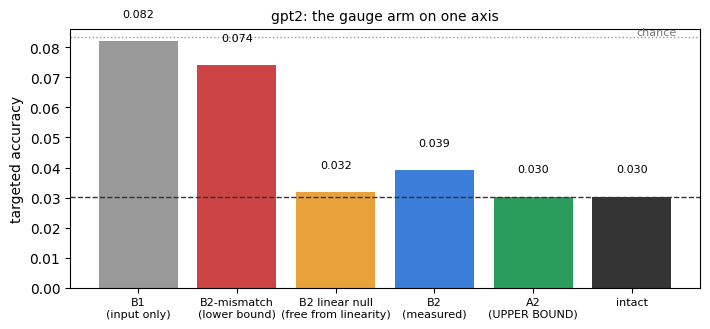

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
labels = ["B1\n(input only)", "B2-mismatch\n(lower bound)", "B2 linear null\n(free from linearity)",
          "B2\n(measured)", "A2\n(UPPER BOUND)", "intact"]
vals   = [R['B1'], R['B2mis'], R['linear_null'], R['B2'], A2, A_INT]
cols   = ["#999", "#c44", "#e9a13b", "#3b7dd8", "#2a9d5c", "#333"]
ax.bar(range(6), vals, color=cols)
ax.axhline(A_INT, ls="--", c="#333", lw=1)
ax.axhline(1/N, ls=":", c="#999", lw=1)
ax.text(5.45, 1/N, "chance", va="bottom", ha="right", fontsize=8, color="#777")
ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("targeted accuracy"); ax.set_title(f"{MODEL}: the gauge arm on one axis", fontsize=10)
for i,v in enumerate(vals): ax.text(i, v+.008, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("gauge_axis.png", dpi=160); plt.show()

In [15]:
out = dict(model=MODEL, intact=A_INT, A2=A2, **R,
           armA=rows,
           circ_defect_logits=float(np.mean([circulance_defect(M) for M in M_int.values()])),
           circularity_E=circularity(E_int))
json.dump(out, open(f"gauge_{MODEL.split('/')[-1]}.json","w"), indent=2)
print(json.dumps(out, indent=2)[:900])
del model; gc.collect(); torch.cuda.empty_cache()

{
  "model": "gpt2",
  "intact": 0.030303030303030304,
  "A2": 0.030303030303030297,
  "B1": 0.08207070707070706,
  "B2": 0.03926767676767677,
  "B2mis": 0.07411616161616162,
  "linear_null": 0.03181818181818182,
  "c_lin": 0.9714697338980669,
  "gram_defect": 0.4054014331555386,
  "armA": [
    {
      "s": 1,
      "variant": "fixed",
      "acc": 0.030303030303030304,
      "dev": 0.0
    },
    {
      "s": 1,
      "variant": "original",
      "acc": 0.03282828282828283,
      "dev": 0.0025252525252525276
    },
    {
      "s": 2,
      "variant": "fixed",
      "acc": 0.030303030303030304,
      "dev": 0.0
    },
    {
      "s": 2,
      "variant": "original",
      "acc": 0.030303030303030304,
      "dev": 0.0
    },
    {
      "s": 3,
      "variant": "fixed",
      "acc": 0.030303030303030304,
      "dev": 0.0
    },
    {
      "s": 3,
      "variant": "original",
      "acc
